# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
from src.alpha_search import FindAlphaSweepDS

# Load existing results and run correlation analysis
finder2 = FindAlphaSweepDS('output/draft3_run/')

# Or run components individually
finder2.load_existing_results()
finder2.compute_dg1_mg1_ratios()

Creating directory: output/draft3_run//alpha_search...Directory exists. Skipping.
Loading existing results from output/draft3_run//alpha_search/alphas_repl1.csv
Loaded 440 rows of results
Computing DG1/MG1 ratios...
DG1/MG1 ratios computed successfully
Saved ratios tooutput/draft3_run//alpha_search/dg1_mg1_ratios.csv

dm_ratio
replicate alpha gene          
1         4     DSE1  1.000312
          6     DSE1  1.000001
          8     DSE1  1.119939
          10    DSE1       1.0
          12    DSE1       1.0
...                        ...
2         38    CTS1       1.0
          40    CTS1       1.0
          42    CTS1       1.0
          44    CTS1       1.0
          46    CTS1       1.0

[440 rows x 1 columns]

Applying threshold of 1.6 to ratios...
Replicate 1 feasible range: (30, 44)
Replicate 2 feasible range: (26, 46)
Saved figure to: output/draft3_run//alpha_search/dg1_mg1_ratio_analysis.png
Ratio analysis plot saved to output/draft3_run//alpha_search/dg1_mg1_ratio_analysis.png


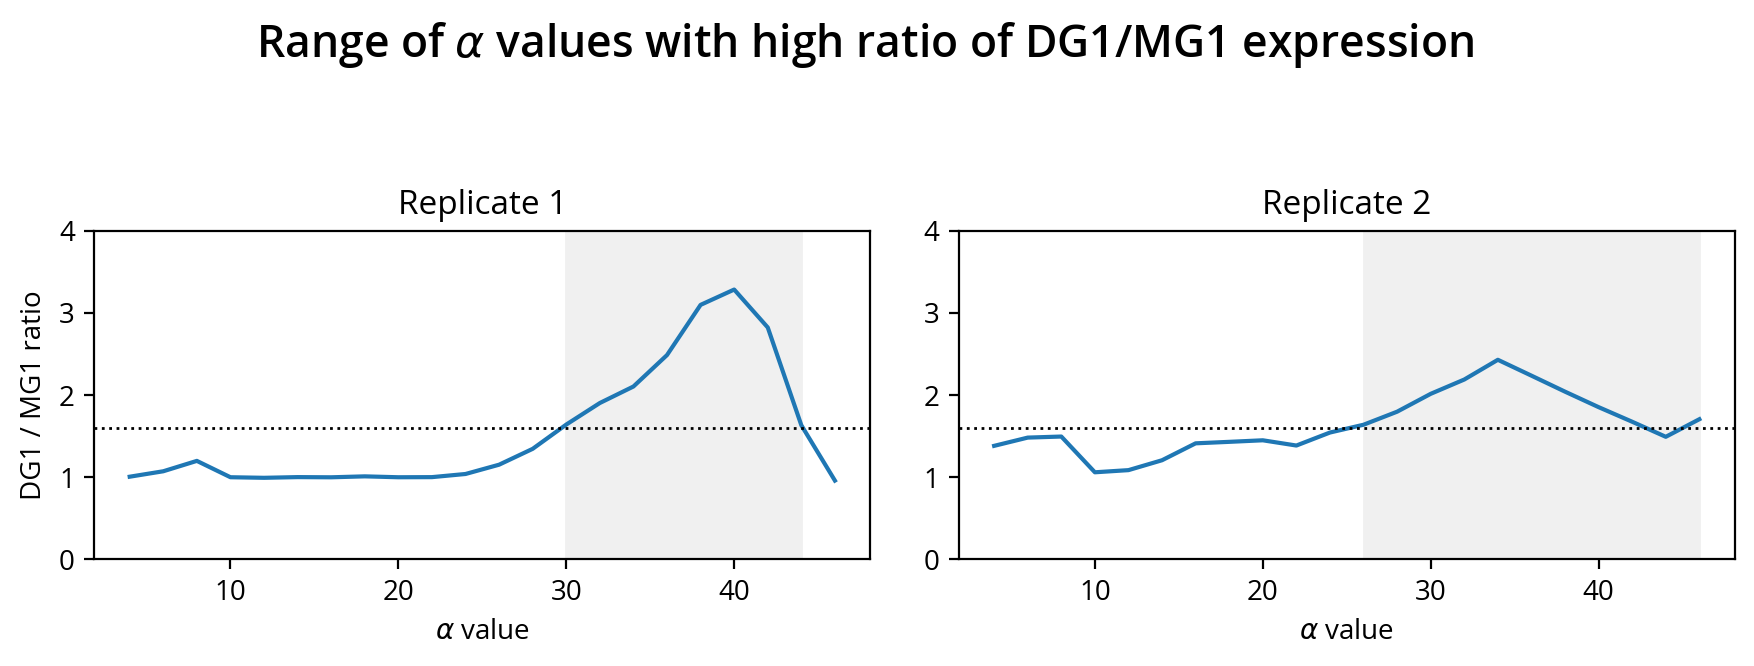

In [4]:
finder2.threshold_ratios(1.6)
finder2.plot_ratio_analysis()

In [5]:
finder2.compute_correlations()

Computing correlations between alpha combinations...
Testing 22x22 = 484 combinations
00:00:09.538
00:00:19.261
00:00:28.868
00:00:38.321
00:00:47.751
00:00:57.210
00:01:06.703
00:01:16.496
00:01:26.239
00:01:35.790
00:01:45.376
00:01:55.046
00:02:04.704
00:02:14.372
00:02:24.622
00:02:34.476
00:02:44.314
00:02:54.146
00:03:03.985
00:03:14.027
00:03:24.828
00:03:34.798
Correlation computation completed


correlation       p_value  n_points
alpha1 alpha2 gene                                      
4      4      DSE1      0.256070  3.644940e-07       384
              DSE2      0.411283  4.164731e-17       384
              DSE3      0.698608  1.687284e-57       384
              DSE4      0.731250  1.896034e-65       384
              ASH1      0.691218  7.577004e-56       384
...                          ...           ...       ...
46     46     EGT2      0.377825  1.779045e-14       384
              AMN1      0.500868  8.874679e-26       384
              PRY3      0.566643  5.392836e-34       384
              SCW11     0.545354  3.901601e-31       384
              CTS1      0.994004  0.000000e+00       384

[4840 rows x 3 columns]

In [37]:
finder2.plot_correlation_heatmap()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/09/f2kb1zq9485dc8jvk0sbkbcr0000gn/T/ipykernel_9380/3895487916.py", line 1, in <module>
    finder2.plot_correlation_heatmap()
  File "/Users/trung/Research/deconvolution-python/src/alpha_search.py", line 432, in plot_correlation_heatmap
    raise ValueError("Correlations not computed. Run compute_correlations() first.")
ValueError: Correlations not computed. Run compute_correlations() first.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2105, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/Users/trung/opt/anacond

In [35]:
all_pairs = finder2.find_optimal_alpha_pairs()

Combined gene results saved to output/draft3_run//alpha_search/combined_gene_results.csv
Saved figure to: output/draft3_run//alpha_search/combined_gene_deconvolution.png
Combined gene figures saved to output/draft3_run//alpha_search/combined_gene_deconvolution.png


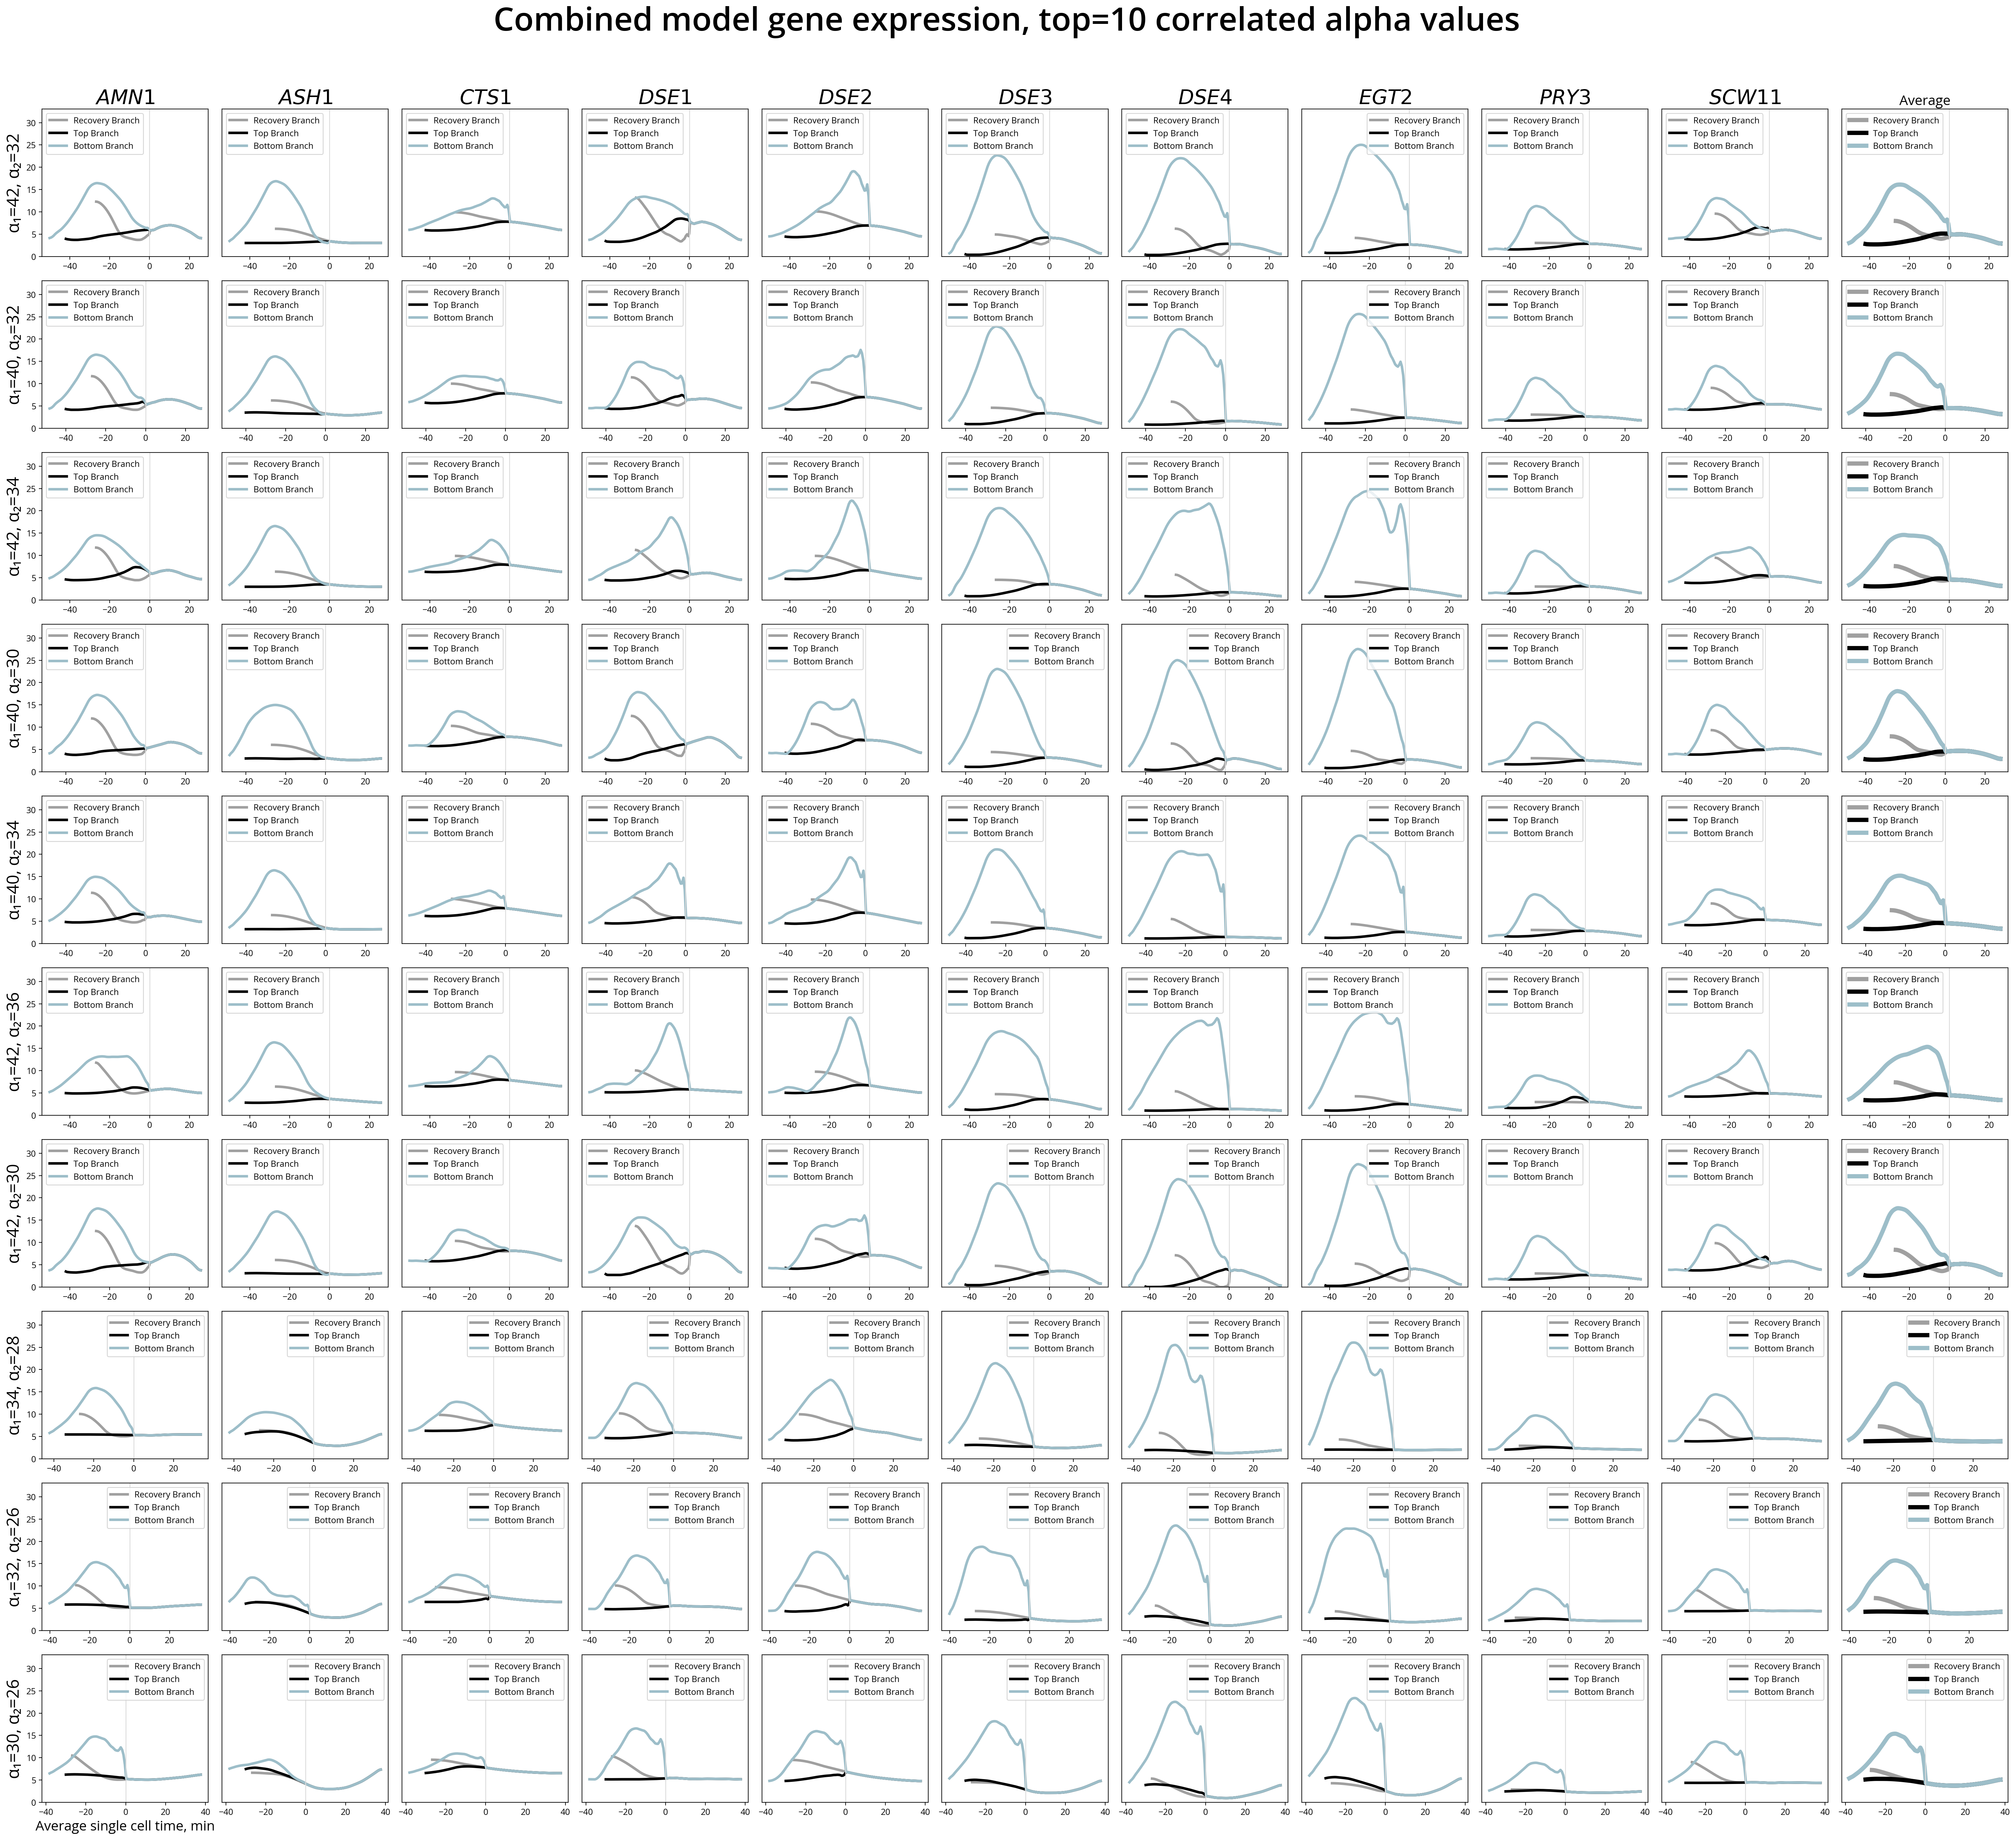

In [33]:
finder2.save_combined_gene_results()
fig = finder2.save_combined_gene_figures()

In [20]:
finder2.run_combined_origin_deconvolution(top_n_pairs=10)

Top 10 optimal alpha pairs within feasible ranges:
               correlation
alpha1 alpha2             
42     32         0.922780
40     32         0.918591
42     34         0.909559
40     30         0.875372
       34         0.873510
42     36         0.855471
       30         0.852440
34     28         0.831227
32     26         0.826913
30     26         0.819051
Running combined origin deconvolution for 10 alpha pairs...
Alphas: (42, 32)
Deconvolving origin: oridb_10
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:00:27.064
Deconvolving origin: oridb_295
Imputing timepoint 50 as average of 40 a

Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:10:02.091
Deconvolving origin: oridb_295
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:10:40.539
Deconvolving origin: oridb_289
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity fu

Disabling copy correction, using identity functions for N, b, and fr

 - 00:20:07.992
Deconvolving origin: oridb_289
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:20:32.594
Deconvolving origin: oridb_193
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity fu


 - 00:30:05.123
Deconvolving origin: oridb_193
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:30:50.306
Deconvolving origin: oridb_558
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:31:32.362
Deconvolving origin: oridb_

Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:40:45.539
Deconvolving origin: oridb_498
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:41:19.325
Deconvolving origin: oridb_68
Imputing timepoint 50 as average of 40 and 60

0         1         2         3         4    \
alphas   origin_id                                                     
(42, 32) oridb_10   0.575725  0.575772  0.575866  0.576007  0.576196   
         oridb_295  0.888708  0.889687  0.891632  0.894684  0.898850   
         oridb_289  1.618944  1.619214  1.619751  1.620553  1.621612   
         oridb_193  1.944193  1.943906  1.943331  1.942469  1.941318   
         oridb_558  2.078837  2.078839  2.078843  2.078841  2.078827   
...                      ...       ...       ...       ...       ...   
(30, 26) oridb_193  1.865249  1.864684  1.863560  1.861877  1.859647   
         oridb_558  2.051149  2.050738  2.049919  2.048692  2.047061   
         oridb_498  1.586208  1.587038  1.588703  1.591185  1.594480   
         oridb_68   1.453807  1.454246  1.455139  1.456513  1.458375   
         oridb_817  0.909491  0.909376  0.909150  0.908810  0.908362   

                         5         6         7         8         9    ...  \
alphas   origin_id                                                    ...   
(42, 32) oridb_10   0.576432  0.576717  0.577053  0.577439  0.577877  ...   
         oridb_295  0.904205  0.910722  0.918369  0.927078  0.936463  ...   
         oridb_289  1.622900  1.624403  1.626121  1.628039  1.630127  ...   
         oridb_193  1.939866  1.938109  1.936050  1.933686  1.931017  ...   
         oridb_558  2.078823  2.078821  2.078802  2.078755  2.078632  ...   
...                      ...       ...       ...       ...       ...  ...   
(30, 26) oridb_193  1.856922  1.853721  1.850048  1.845919  1.841365  ...   
         oridb_558  2.045048  2.042659  2.039884  2.036735  2.033245  ...   
         oridb_498  1.598661  1.603714  1.609660  1.616480  1.623992  ...   
         oridb_68   1.460798  1.463807  1.467425  1.471668  1.476510  ...   
         oridb_817  0.907841  0.907263  0.906620  0.905926  0.905224  ...   

                         275       276  277  278  279  280  281  282  283  284  
alphas   origin_id                                                              
(42, 32) oridb_10   0.351620  0.735378  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_295  0.698486  2.031781  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_289  0.634712  1.132684  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_193  0.621063  1.431138  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_558  1.649912  1.854254  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
...                      ...       ...  ...  ...  ...  ...  ...  ...  ...  ...  
(30, 26) oridb_193       NaN       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_558       NaN       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_498       NaN       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_68        NaN       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
         oridb_817       NaN       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[80 rows x 285 columns]

In [21]:
finder2.save_combined_origin_results()

Combined origin results saved to output/draft3_run//alpha_search/combined_origin_results.csv


Saved figure to: output/draft3_run//alpha_search/combined_origin_deconvolution.png
Combined origin figures saved to output/draft3_run//alpha_search/combined_origin_deconvolution.png


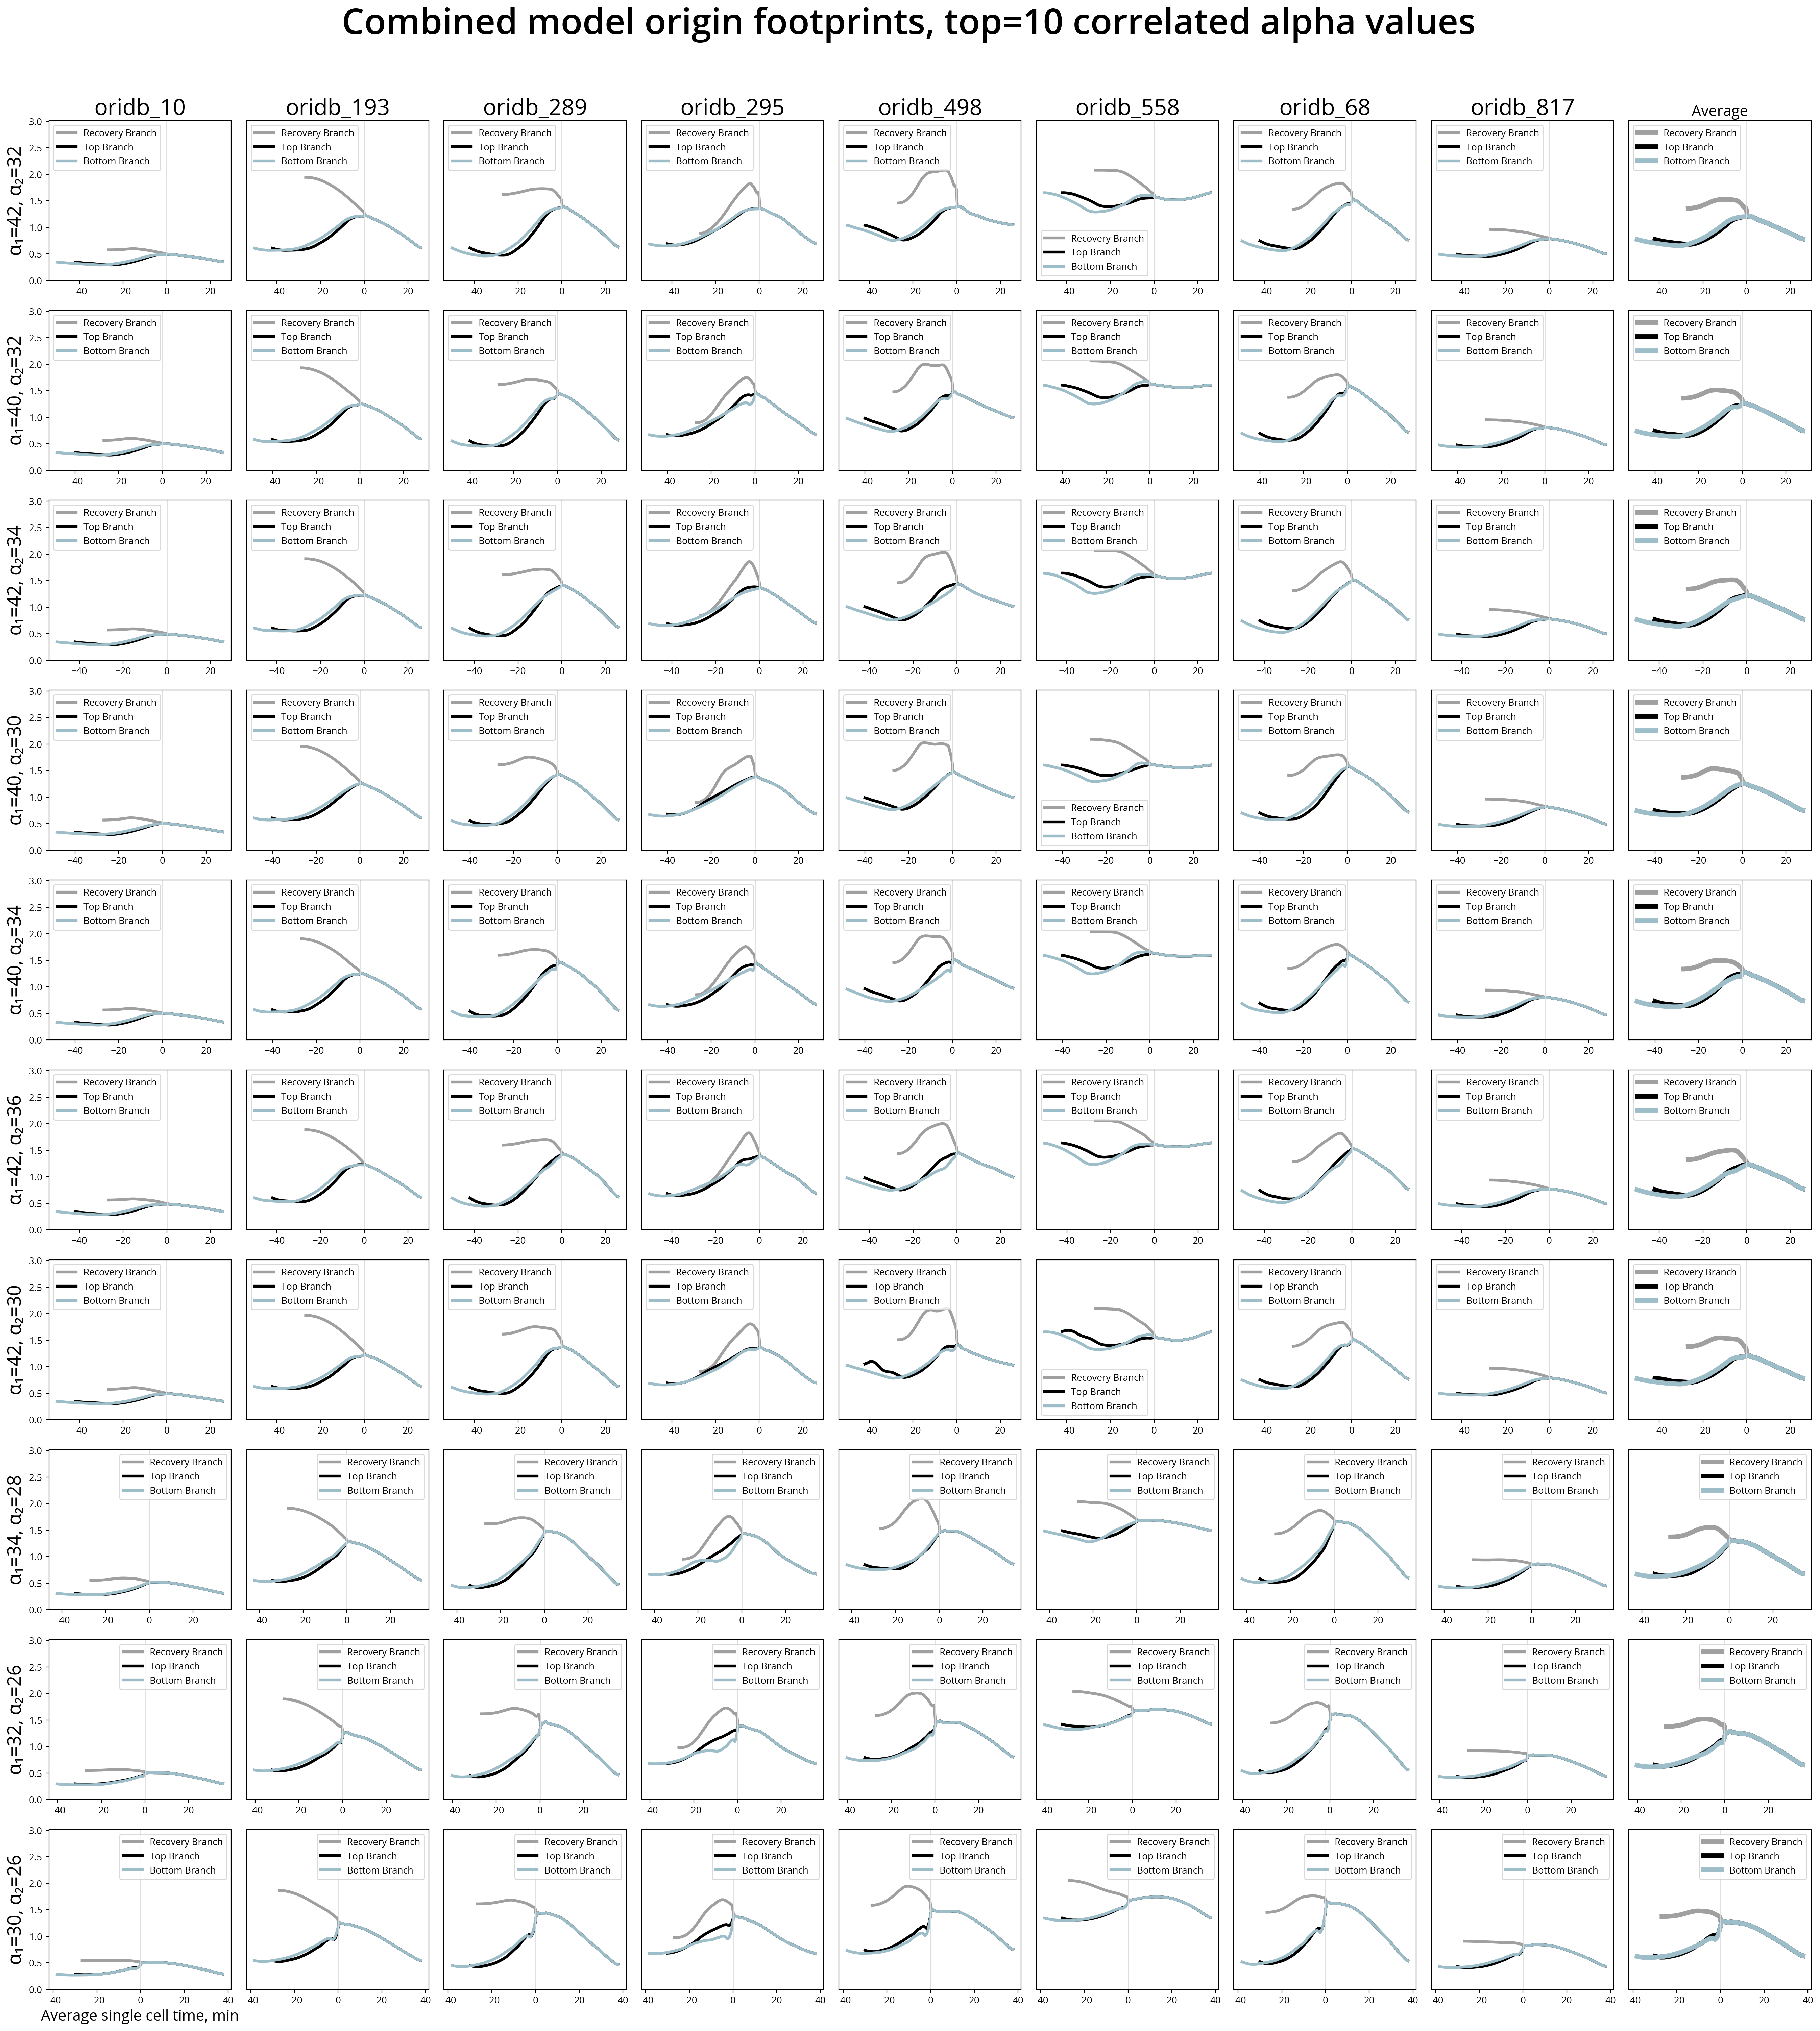

In [34]:
fig = finder2.save_combined_origin_figures()